# Hierarchical analysis

In [34]:
!!pip install squarify
!!pip install country-converter

['Requirement already satisfied: country-converter in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (1.3.1)',
 'Requirement already satisfied: pandas>=1.0 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from country-converter) (2.3.2)',
 'Requirement already satisfied: numpy>=1.26.0 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from pandas>=1.0->country-converter) (2.3.3)',
 'Requirement already satisfied: python-dateutil>=2.8.2 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from pandas>=1.0->country-converter) (2.9.0.post0)',
 'Requirement already satisfied: pytz>=2020.1 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from pandas>=1.0->country-converter) (2025.2)',
 'Requirement already satisfied: tzdata>=2022.7 in c:\\users\\yusel\\documents\\github\\visualization-tools-i

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import squarify
import country_converter as coco
import warnings

In [ ]:
df = pd.read_csv('data/01_gdp_population.csv')

In [40]:
print(f"Dimensiones: {df.shape[0]} países × {df.shape[1]} variables")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nPrimeros registros:")
display(df.head())

Dimensiones: 193 países × 4 variables

Columnas: ['Country Name', 'Country Code', 'Population', 'GDP']

Primeros registros:


,Country Name,Country Code,Population,GDP
0,Afghanistan,AFG,42647492,0.000000
1,Angola,AGO,37885849,2122.083690
2,Albania,ALB,2714617,10011.627986
3,Andorra,AND,81938,49303.673390
4,United Arab Emirates,ARE,10876981,49377.564338


In [39]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  193 non-null    object 
 1   Country Code  193 non-null    object 
 2   Population    193 non-null    int64  
 3   GDP           193 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 6.2+ KB
None
         Population            GDP
count  1.930000e+02     193.000000
mean   4.196121e+07   16364.426623
std    1.508721e+08   23447.224829
min    9.646000e+03       0.000000
25%    2.126324e+06    1743.988884
50%    9.515236e+06    6416.097090
75%    3.196496e+07   22771.416892
max    1.450936e+09  137516.587324


In [42]:
df_clean = df.copy()
df_clean = df_clean[df_clean['GDP'] > 0].copy()

print(f"\n Después de limpieza: {df_clean.shape[0]} países con datos completos")


 Después de limpieza: 175 países con datos completos


In [ ]:
cc = coco.CountryConverter()

# Convertir códigos a continentes
df_clean['Continent'] = cc.pandas_convert(
    series=df_clean['Country Code'], 
    to='continent'
)

def ajustar_region(row):
    """
    Personaliza la clasificación continental para el análisis de TCF
    Separa América Latina de Norteamérica y usa nombres en español
    """
    if row['Continent'] == 'Americas' and row['Country Code'] not in ['USA', 'CAN']:
        return 'América Latina'
    elif row['Continent'] == 'Americas':
        return 'Norteamérica'
    elif row['Continent'] == 'Africa':
        return 'África'
    elif row['Continent'] == 'Oceania':
        return 'Oceanía'
    elif row['Continent'] == 'Europe':
        return 'Europa'
    elif row['Continent'] == 'Asia':
        return 'Asia'
    else:
        return row['Continent']

df_clean['Region'] = df_clean.apply(ajustar_region, axis=1)
df_clean['Region'] = df_clean['Region'].fillna('Otros')
# Crear variables adicionales para análisis
df_clean['GDP_billions'] = df_clean['GDP'] * df_clean['Population'] / 1e9
df_clean['Population_millions'] = df_clean['Population'] / 1e6

print("\n Distribución de países por región:")
region_counts = df_clean['Region'].value_counts()
display(region_counts)

print("\n PIB Total por Región (miles de millones USD):")
regional_gdp = df_clean.groupby('Region')['GDP_billions'].sum().sort_values(ascending=False)
display(regional_gdp.round(2))


 Distribución de países por región:


Region
África     51
Europa     40
Asia       40
America    33
Oceanía    11
Name: count, dtype: int64


 PIB Total por Región (miles de millones USD):


Region
America    38077.31
Asia       37289.39
Europa     27093.26
África      2648.92
Oceanía     2056.02
Name: GDP_billions, dtype: float64

In [48]:
import country_converter as coco

cc = coco.CountryConverter()

print(" Clasificando países por continente/región...")

# Convertir códigos a continentes automáticamente
df_clean['Continent'] = cc.pandas_convert(
    series=df_clean['Country Code'], 
    to='continent'
)

# Función para ajustar clasificación según necesidades de TCF
def ajustar_region(row):
    """
    Personaliza la clasificación continental para el análisis de TCF
    Separa América Latina de Norteamérica y usa nombres en español
    """
    if row['Continent'] == 'Americas' and row['Country Code'] not in ['USA', 'CAN']:
        return 'América Latina'
    elif row['Continent'] == 'Americas':
        return 'Norteamérica'
    elif row['Continent'] == 'Africa':
        return 'África'
    elif row['Continent'] == 'Oceania':
        return 'Oceanía'
    elif row['Continent'] == 'Europe':
        return 'Europa'
    elif row['Continent'] == 'Asia':
        return 'Asia'
    else:
        return row['Continent']

# Aplicar clasificación personalizada
df_clean['Region'] = df_clean.apply(ajustar_region, axis=1)

# Manejar posibles valores no reconocidos
df_clean['Region'] = df_clean['Region'].fillna('Otros')
print(" Distribución de países por región:")
region_counts = df_clean['Region'].value_counts()
display(region_counts)

# Análisis agregado por región
print("\n PIB Total por Región (en miles de millones USD):")
regional_gdp = df_clean.groupby('Region')['GDP_billions'].sum().sort_values(ascending=False)
display(regional_gdp)


 Clasificando países por continente/región...
 Distribución de países por región:


Region
África     51
Europa     40
Asia       40
America    33
Oceanía    11
Name: count, dtype: int64


 PIB Total por Región (en miles de millones USD):


Region
America    38077.310446
Asia       37289.394759
Europa     27093.261296
África      2648.922397
Oceanía     2056.018325
Name: GDP_billions, dtype: float64

## MÉTRICAS CLAVE PARA DECISIÓN DE INVERSIÓN

In [50]:
# Análisis agregado por región
regional_analysis = df_clean.groupby('Region').agg({
    'GDP_billions': 'sum',
    'GDP': 'mean',
    'Population': 'sum',
    'Country Name': 'count'
}).round(2)

regional_analysis.columns = ['PIB Total (B USD)', 'PIB per cápita Promedio', 
                              'Población Total', 'Número de Países']
regional_analysis = regional_analysis.sort_values('PIB Total (B USD)', ascending=False)

print("\n RESUMEN EJECUTIVO POR REGIÓN:")
display(regional_analysis)

# Top países por PIB Total
print("\n TOP 15 PAÍSES POR PIB TOTAL (Mayor Capacidad de Compra):")
top_countries = df_clean.nlargest(15, 'GDP_billions')[
    ['Country Name', 'Region', 'GDP_billions', 'GDP', 'Population_millions']
].copy()
top_countries.columns = ['País', 'Región', 'PIB Total (B USD)', 
                         'PIB per cápita', 'Población (M)']
display(top_countries.round(2))


 RESUMEN EJECUTIVO POR REGIÓN:


,PIB Total (B USD),PIB per cápita Promedio,Población Total,Número de Países
Region,,,,
America,38077.31,16749.47,1000399073,33
Asia,37289.39,16606.89,4565759025,40
Europa,27093.26,40842.83,740945177,40
África,2648.92,2885.49,1365780509,51
Oceanía,2056.02,14586.68,45710762,11



 TOP 15 PAÍSES POR PIB TOTAL (Mayor Capacidad de Compra):


,País,Región,PIB Total (B USD),PIB per cápita,Población (M)
182,United States,America,29184.89,85809.90,340.11
32,China,Asia,18743.80,13303.15,1408.98
44,Germany,Europa,4659.93,55800.22,83.51
86,Japan,Asia,4026.21,32475.89,123.98
77,India,Asia,3912.69,2696.66,1450.94
61,United Kingdom,Europa,3643.83,52636.79,69.23
58,France,Europa,3162.08,46150.49,68.52
83,Italy,Europa,2372.77,40226.05,58.99
29,Canada,America,2241.25,54282.62,41.29
23,Brazil,America,2179.41,10280.31,212.00


 VISUALIZACIÓN 1: TREEMAP ESTÁTICO
Propósito: Vista general de capacidad de compra por región y país


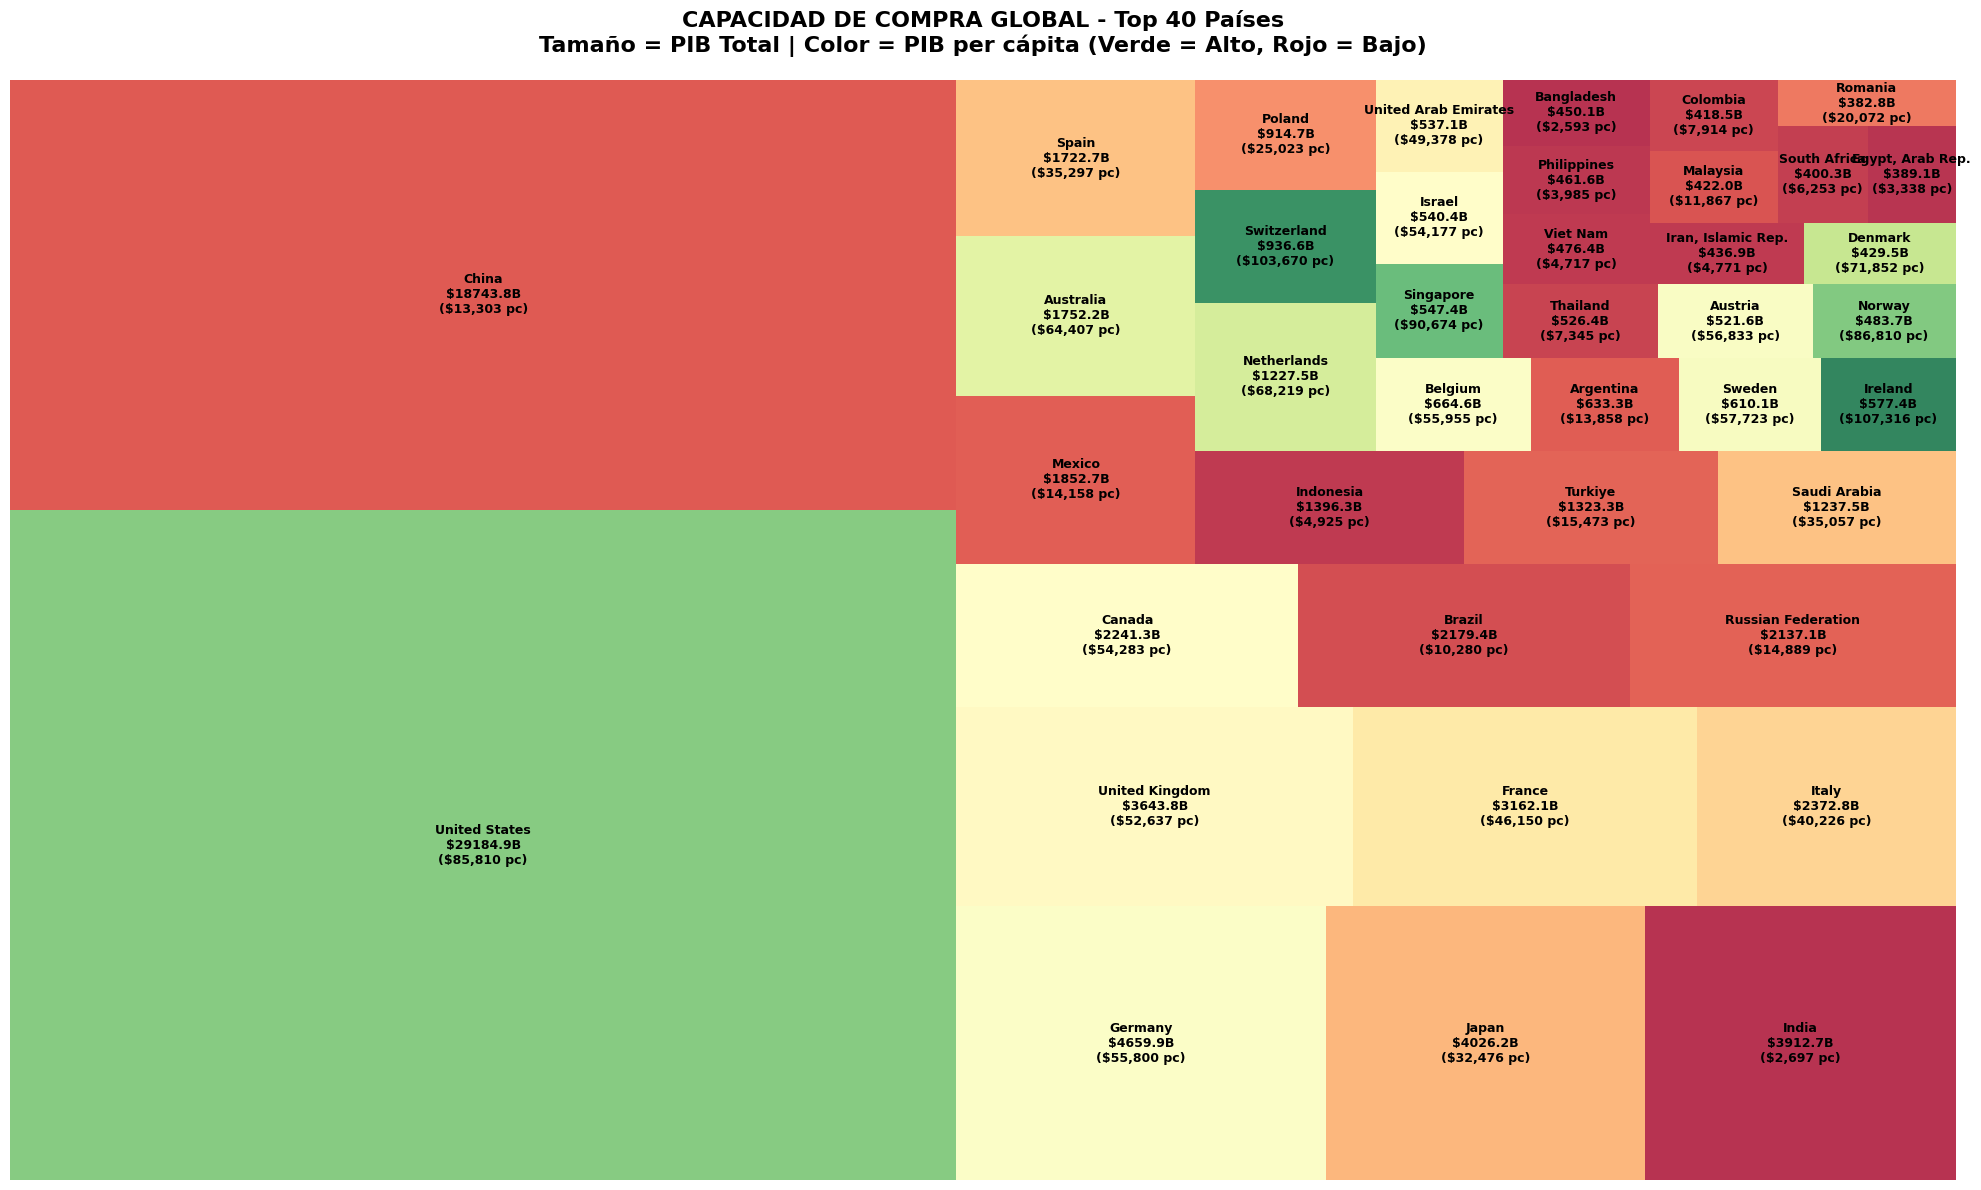


 INSIGHT CLAVE:
   Los países más grandes representan los mercados con mayor capacidad
   de compra total. El color indica el poder adquisitivo individual.


In [53]:
print(" VISUALIZACIÓN 1: TREEMAP ESTÁTICO")
print("Propósito: Vista general de capacidad de compra por región y país")


# Preparar datos para treemap - Top 40 países
df_treemap = df_clean.nlargest(40, 'GDP_billions').copy()

fig, ax = plt.subplots(1, 1, figsize=(20, 12))

# Calcular color basado en PIB per cápita
norm = plt.Normalize(vmin=df_treemap['GDP'].min(), vmax=df_treemap['GDP'].max())
colors = plt.cm.RdYlGn(norm(df_treemap['GDP']))

# Crear treemap
squarify.plot(
    sizes=df_treemap['GDP_billions'],
    label=[f"{row['Country Name']}\n${row['GDP_billions']:.1f}B\n(${row['GDP']:,.0f} pc)" 
           for _, row in df_treemap.iterrows()],
    color=colors,
    alpha=0.8,
    text_kwargs={'fontsize': 9, 'weight': 'bold'},
    ax=ax
)

ax.set_title('CAPACIDAD DE COMPRA GLOBAL - Top 40 Países\n' + 
             'Tamaño = PIB Total | Color = PIB per cápita (Verde = Alto, Rojo = Bajo)',
             fontsize=16, weight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n INSIGHT CLAVE:")
print("   Los países más grandes representan los mercados con mayor capacidad")
print("   de compra total. El color indica el poder adquisitivo individual.")


In [69]:
print("\n" + "=" * 80)
print(" VISUALIZACIÓN 2: TREEMAP INTERACTIVO JERÁRQUICO")
print("Propósito: Exploración interactiva de Región → País")
print("=" * 80)

# Preparar datos para treemap interactivo
df_interactive = df_clean.copy()

df_interactive['PIB_label'] = df_interactive['GDP_billions'].apply(lambda x: f"${x:.1f}B")
df_interactive['GDP_pc_label'] = df_interactive['GDP'].apply(lambda x: f"${x:,.0f}")

fig = px.treemap(
    df_interactive,
    path=['Region', 'Country Name'],
    values='GDP_billions',
    color='GDP',
    color_continuous_scale='RdYlGn',
    hover_data={
        'GDP_billions': ':.2f',
        'GDP': ':.0f',
        'Population_millions': ':.2f'
    },
    labels={
        'GDP_billions': 'PIB Total (B USD)',
        'GDP': 'PIB per cápita (USD)',
        'Population_millions': 'Población (M)',
        'Region': 'Región',
        'Country Name': 'País'
    },
    title='<b>JERARQUÍA DE CAPACIDAD DE COMPRA: Región → País</b><br>' +
          '<sub>Haz click en las regiones para explorar países | Tamaño = PIB Total | Color = PIB per cápita</sub>'
)

fig.update_layout(
    height=700,
    font=dict(size=12),
    margin=dict(t=100, l=10, r=10, b=10)
)

fig.update_traces(
    textposition="middle center",
    textfont_size=11,
    marker=dict(line=dict(width=2, color='white'))
)

fig.show()

print("\n INSIGHT CLAVE:")
print("   Haz click en cada región para ver la distribución detallada de países.")
print("   Identifica mercados grandes (tamaño) con alto poder adquisitivo (verde).")


 VISUALIZACIÓN 2: TREEMAP INTERACTIVO JERÁRQUICO
Propósito: Exploración interactiva de Región → País



 INSIGHT CLAVE:
   Haz click en cada región para ver la distribución detallada de países.
   Identifica mercados grandes (tamaño) con alto poder adquisitivo (verde).


In [70]:
print("\n" + "=" * 80)
print(" VISUALIZACIÓN 3: SUNBURST CHART")
print("Propósito: Visualizar proporción y jerarquía de mercados")
print("=" * 80)

# Top 50 países para mejor visualización
df_sunburst = df_clean.nlargest(50, 'GDP_billions').copy()

fig = px.sunburst(
    df_sunburst,
    path=['Region', 'Country Name'],
    values='GDP_billions',
    color='GDP',
    color_continuous_scale='Viridis',
    hover_data={
        'GDP_billions': ':.2f',
        'GDP': ':.0f'
    },
    labels={
        'GDP_billions': 'PIB Total (B USD)',
        'GDP': 'PIB per cápita (USD)',
        'Region': 'Región',
        'Country Name': 'País'
    },
    title='<b>ESTRUCTURA JERÁRQUICA DE MERCADOS - Top 50</b><br>' +
          '<sub>Centro = Regiones | Anillos exteriores = Países | Color = PIB per cápita</sub>'
)

fig.update_layout(
    height=700,
    font=dict(size=12),
    margin=dict(t=100, l=10, r=10, b=10)
)

fig.update_traces(
    textfont_size=10,
    marker=dict(line=dict(width=2, color='white'))
)

fig.show()

print("\n INSIGHT CLAVE:")
print("   Las secciones más grandes indican mayor participación en el mercado global.")
print("   Haz click para explorar la contribución de cada país dentro de su región.")


 VISUALIZACIÓN 3: SUNBURST CHART
Propósito: Visualizar proporción y jerarquía de mercados



 INSIGHT CLAVE:
   Las secciones más grandes indican mayor participación en el mercado global.
   Haz click para explorar la contribución de cada país dentro de su región.


In [71]:
print("\n" + "=" * 80)
print(" VISUALIZACIÓN 4: COMPARACIÓN REGIONAL DETALLADA")
print("Propósito: Comparar regiones según múltiples dimensiones")
print("=" * 80)

# Crear subplots para comparación multi-dimensional
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'PIB Total por Región (Capacidad de Compra)',
        'PIB per cápita Promedio (Poder Adquisitivo)',
        'Número de Países por Región',
        'Población Total por Región'
    ),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

regional_summary = df_clean.groupby('Region').agg({
    'GDP_billions': 'sum',
    'GDP': 'mean',
    'Country Name': 'count',
    'Population': 'sum'
}).round(2)

regional_summary = regional_summary.sort_values('GDP_billions', ascending=False)

colors_sequential = px.colors.sequential.Viridis

# Subplot 1: PIB Total
fig.add_trace(
    go.Bar(
        x=regional_summary.index,
        y=regional_summary['GDP_billions'],
        marker_color=colors_sequential[2],
        text=regional_summary['GDP_billions'].round(0),
        textposition='outside',
        name='PIB Total'
    ),
    row=1, col=1
)

# Subplot 2: PIB per cápita
fig.add_trace(
    go.Bar(
        x=regional_summary.index,
        y=regional_summary['GDP'],
        marker_color=colors_sequential[4],
        text=regional_summary['GDP'].round(0),
        textposition='outside',
        name='PIB per cápita'
    ),
    row=1, col=2
)

# Subplot 3: Número de países
fig.add_trace(
    go.Bar(
        x=regional_summary.index,
        y=regional_summary['Country Name'],
        marker_color=colors_sequential[6],
        text=regional_summary['Country Name'],
        textposition='outside',
        name='Países'
    ),
    row=2, col=1
)

# Subplot 4: Población
fig.add_trace(
    go.Bar(
        x=regional_summary.index,
        y=regional_summary['Population'] / 1e6,
        marker_color=colors_sequential[8],
        text=(regional_summary['Population'] / 1e6).round(0),
        textposition='outside',
        name='Población (M)'
    ),
    row=2, col=2
)

# Actualizar layout
fig.update_xaxes(tickangle=-45)
fig.update_yaxes(title_text="Miles de millones USD", row=1, col=1)
fig.update_yaxes(title_text="USD per cápita", row=1, col=2)
fig.update_yaxes(title_text="Cantidad", row=2, col=1)
fig.update_yaxes(title_text="Millones", row=2, col=2)

fig.update_layout(
    height=800,
    showlegend=False,
    title_text="<b>ANÁLISIS COMPARATIVO REGIONAL - TERRA COTTA FOODS</b>",
    title_font_size=16,
    font=dict(size=10)
)

fig.show()

print("\n INSIGHT CLAVE:")
print("   Vista completa de las dimensiones clave para evaluar regiones.")
print("   Combina capacidad de compra (PIB Total) con poder adquisitivo (PIB pc).")


 VISUALIZACIÓN 4: COMPARACIÓN REGIONAL DETALLADA
Propósito: Comparar regiones según múltiples dimensiones



 INSIGHT CLAVE:
   Vista completa de las dimensiones clave para evaluar regiones.
   Combina capacidad de compra (PIB Total) con poder adquisitivo (PIB pc).


In [72]:

print(" ANÁLISIS ESTRATÉGICO: SEGMENTACIÓN DE MERCADOS")


# Crear segmentación basada en PIB Total y PIB per cápita
df_clean['GDP_total_percentile'] = pd.qcut(df_clean['GDP_billions'], 
                                            q=3, 
                                            labels=['Bajo', 'Medio', 'Alto'])

df_clean['GDP_pc_percentile'] = pd.qcut(df_clean['GDP'], 
                                         q=3, 
                                         labels=['Bajo', 'Medio', 'Alto'])

# Crear matriz de segmentación
df_clean['Segmento_Mercado'] = (df_clean['GDP_total_percentile'].astype(str) + 
                                 ' PIB Total / ' + 
                                 df_clean['GDP_pc_percentile'].astype(str) + 
                                 ' PIB pc')

# Identificar mercados prioritarios (Alto PIB Total)
mercados_prioritarios = df_clean[df_clean['GDP_total_percentile'] == 'Alto'].copy()
mercados_prioritarios = mercados_prioritarios.sort_values('GDP_billions', ascending=False)

print("\n🌟 MERCADOS PRIORITARIOS PARA INVERSIÓN (Alto PIB Total):")
print("-" * 80)
print("Estos países representan la mayor capacidad de compra agregada\n")

priority_display = mercados_prioritarios[[
    'Country Name', 'Region', 'GDP_billions', 'GDP', 'Population_millions'
]].copy()

priority_display.columns = ['País', 'Región', 'PIB Total (B USD)', 
                            'PIB per cápita', 'Población (M)']
display(priority_display.round(2))

# Crear visualización de segmentación
fig = px.scatter(
    df_clean,
    x='GDP',
    y='GDP_billions',
    size='Population',
    color='Region',
    hover_name='Country Name',
    hover_data={
        'GDP': ':.0f',
        'GDP_billions': ':.2f',
        'Population_millions': ':.2f'
    },
    labels={
        'GDP': 'PIB per cápita (USD) - Poder Adquisitivo',
        'GDP_billions': 'PIB Total (B USD) - Capacidad de Compra',
        'Population': 'Población',
        'Region': 'Región'
    },
    title='<b>MATRIZ DE SEGMENTACIÓN DE MERCADOS</b><br>' +
          '<sub>Eje X = Poder Adquisitivo | Eje Y = Capacidad de Compra | Tamaño = Población</sub>',
    log_x=True,
    log_y=True
)

fig.add_hline(y=df_clean['GDP_billions'].quantile(0.67), 
              line_dash="dash", line_color="red",
              annotation_text="Umbral Alto PIB Total")

fig.add_vline(x=df_clean['GDP'].quantile(0.67), 
              line_dash="dash", line_color="green",
              annotation_text="Umbral Alto PIB pc")

fig.update_layout(
    height=700,
    font=dict(size=12),
    xaxis=dict(gridcolor='lightgray'),
    yaxis=dict(gridcolor='lightgray')
)

fig.show()

print("\nINSIGHT CLAVE:")
print("   Cuadrante superior derecho = Mercados ideales (alto poder adquisitivo + gran mercado)")
print("   Cuadrante superior izquierdo = Mercados grandes pero con menor poder adquisitivo")

 ANÁLISIS ESTRATÉGICO: SEGMENTACIÓN DE MERCADOS

🌟 MERCADOS PRIORITARIOS PARA INVERSIÓN (Alto PIB Total):
--------------------------------------------------------------------------------
Estos países representan la mayor capacidad de compra agregada



,País,Región,PIB Total (B USD),PIB per cápita,Población (M)
182,United States,America,29184.89,85809.90,340.11
32,China,Asia,18743.80,13303.15,1408.98
44,Germany,Europa,4659.93,55800.22,83.51
86,Japan,Asia,4026.21,32475.89,123.98
77,India,Asia,3912.69,2696.66,1450.94
61,United Kingdom,Europa,3643.83,52636.79,69.23
58,France,Europa,3162.08,46150.49,68.52
83,Italy,Europa,2372.77,40226.05,58.99
29,Canada,America,2241.25,54282.62,41.29
23,Brazil,America,2179.41,10280.31,212.00



INSIGHT CLAVE:
   Cuadrante superior derecho = Mercados ideales (alto poder adquisitivo + gran mercado)
   Cuadrante superior izquierdo = Mercados grandes pero con menor poder adquisitivo


In [75]:

print(" RECOMENDACIONES ESTRATÉGICAS PARA TERRA COTTA FOODS")

# Top 5 regiones por PIB Total
top_regions = regional_gdp.head(5)

print("\n1  REGIONES PRIORITARIAS PARA CENTROS DE DISTRIBUCIÓN:")
print("-" * 80)
for i, (region, gdp) in enumerate(top_regions.items(), 1):
    num_paises = df_clean[df_clean['Region'] == region].shape[0]
    gdp_pc_avg = df_clean[df_clean['Region'] == region]['GDP'].mean()
    print(f"   #{i} {region}:")
    print(f"       • PIB Total: ${gdp:.2f}B USD")
    print(f"       • PIB per cápita promedio: ${gdp_pc_avg:,.0f} USD")
    print(f"       • Países en región: {num_paises}")
    print()

 RECOMENDACIONES ESTRATÉGICAS PARA TERRA COTTA FOODS

1  REGIONES PRIORITARIAS PARA CENTROS DE DISTRIBUCIÓN:
--------------------------------------------------------------------------------
   #1 America:
       • PIB Total: $38077.31B USD
       • PIB per cápita promedio: $16,749 USD
       • Países en región: 33

   #2 Asia:
       • PIB Total: $37289.39B USD
       • PIB per cápita promedio: $16,607 USD
       • Países en región: 40

   #3 Europa:
       • PIB Total: $27093.26B USD
       • PIB per cápita promedio: $40,843 USD
       • Países en región: 40

   #4 África:
       • PIB Total: $2648.92B USD
       • PIB per cápita promedio: $2,885 USD
       • Países en región: 51

   #5 Oceanía:
       • PIB Total: $2056.02B USD
       • PIB per cápita promedio: $14,587 USD
       • Países en región: 11



In [65]:
top_10_countries = df_clean.nlargest(10, 'GDP_billions')

print("\n  TOP 10 PAÍSES RECOMENDADOS PARA INVERSIÓN INMEDIATA:")
print("-" * 80)
for i, (idx, row) in enumerate(top_10_countries.iterrows(), 1):
    print(f"   #{i} {row['Country Name']} ({row['Region']})")
    print(f"       • PIB Total: ${row['GDP_billions']:.2f}B USD")
    print(f"       • PIB per cápita: ${row['GDP']:,.0f} USD")
    print(f"       • Población: {row['Population_millions']:.2f}M")
    
    # Justificación estratégica
    if row['GDP_billions'] > 1000:
        print(f"       ✓ Mercado gigante - Alto potencial de distribución masiva")
    if row['GDP'] > 30000:
        print(f"       ✓ Alto poder adquisitivo - Productos premium viables")
    if row['Population_millions'] > 100:
        print(f"       ✓ Gran base de consumidores - Economías de escala")
    print()

print("\n  CONSIDERACIONES ESTRATÉGICAS CLAVE:")
print("-" * 80)
print("   ✓ Priorizar regiones con PIB Total alto para centros logísticos principales")
print("   ✓ Dentro de cada región, enfocarse en países con mayor PIB per cápita")
print("   ✓ Considerar población como factor de demanda potencial y fuerza laboral")
print("   ✓ Evaluar infraestructura logística y estabilidad política (análisis adicional)")


  TOP 10 PAÍSES RECOMENDADOS PARA INVERSIÓN INMEDIATA:
--------------------------------------------------------------------------------
   #1 United States (America)
       • PIB Total: $29184.89B USD
       • PIB per cápita: $85,810 USD
       • Población: 340.11M
       ✓ Mercado gigante - Alto potencial de distribución masiva
       ✓ Alto poder adquisitivo - Productos premium viables
       ✓ Gran base de consumidores - Economías de escala

   #2 China (Asia)
       • PIB Total: $18743.80B USD
       • PIB per cápita: $13,303 USD
       • Población: 1408.97M
       ✓ Mercado gigante - Alto potencial de distribución masiva
       ✓ Gran base de consumidores - Economías de escala

   #3 Germany (Europa)
       • PIB Total: $4659.93B USD
       • PIB per cápita: $55,800 USD
       • Población: 83.51M
       ✓ Mercado gigante - Alto potencial de distribución masiva
       ✓ Alto poder adquisitivo - Productos premium viables

   #4 Japan (Asia)
       • PIB Total: $4026.21B USD
       

In [74]:

print(" RESUMEN EJECUTIVO - CAPACIDAD DE COMPRA GLOBAL")

total_gdp_global = df_clean['GDP_billions'].sum()
total_population = df_clean['Population'].sum() / 1e9

print(f"\n MERCADO GLOBAL ANALIZADO:")
print(f"   • PIB Total Global: ${total_gdp_global:.2f} Billones USD")
print(f"   • Población Total: {total_population:.2f} Mil Millones")
print(f"   • Países analizados: {df_clean.shape[0]}")
print(f"   • Regiones: {df_clean['Region'].nunique()}")

print(f"\n CONCENTRACIÓN DE CAPACIDAD DE COMPRA:")
top_5_share = (top_10_countries.head(5)['GDP_billions'].sum() / total_gdp_global) * 100
top_10_share = (top_10_countries['GDP_billions'].sum() / total_gdp_global) * 100

print(f"   • Top 5 países representan: {top_5_share:.1f}% del PIB global")
print(f"   • Top 10 países representan: {top_10_share:.1f}% del PIB global")

print(f"\n RECOMENDACIÓN PRINCIPAL:")
print(f"   Establecer centros de distribución en las 3 regiones principales:")
for i, (region, gdp) in enumerate(top_regions.head(3).items(), 1):
    print(f"   {i}. {region} (${gdp:.2f}B PIB Total)")


 RESUMEN EJECUTIVO - CAPACIDAD DE COMPRA GLOBAL

 MERCADO GLOBAL ANALIZADO:
   • PIB Total Global: $107164.91 Billones USD
   • Población Total: 7.72 Mil Millones
   • Países analizados: 175
   • Regiones: 5

 CONCENTRACIÓN DE CAPACIDAD DE COMPRA:
   • Top 5 países representan: 56.5% del PIB global
   • Top 10 países representan: 69.2% del PIB global

 RECOMENDACIÓN PRINCIPAL:
   Establecer centros de distribución en las 3 regiones principales:
   1. America ($38077.31B PIB Total)
   2. Asia ($37289.39B PIB Total)
   3. Europa ($27093.26B PIB Total)


# **Supply risk**

In [ ]:
countries_df = pd.read_csv('./data/01_gdp_population.csv')
countries_df

,Country Name,Country Code,Population,GDP
0,Afghanistan,AFG,42647492,0.000000
1,Angola,AGO,37885849,2122.083690
2,Albania,ALB,2714617,10011.627986
3,Andorra,AND,81938,49303.673390
4,United Arab Emirates,ARE,10876981,49377.564338
...,...,...,...,...
188,Samoa,WSM,218019,4898.771408
189,"Yemen, Rep.",YEM,40583164,0.000000
190,South Africa,ZAF,64007187,6253.371582
191,Zambia,ZMB,21314956,1235.084665


Adding continent to each country for better analysis.

In [ ]:
cc = coco.CountryConverter()

# Convertir códigos a continentes
countries_df['Continent'] = cc.pandas_convert(
    series=countries_df['Country Code'], 
    to='continent'
)

def ajustar_region(row):
    """
    Personaliza la clasificación continental para el análisis de TCF
    Separa América Latina de Norteamérica y usa nombres en español
    """
    if row['Continent'] == 'America' and row['Country Code'] not in ['USA', 'CAN']:
        return 'Latin America'
    elif row['Continent'] == 'America':
        return 'North America'
    elif row['Continent'] == 'Africa':
        return 'Africa'
    elif row['Continent'] == 'Oceania':
        return 'Oceania'
    elif row['Continent'] == 'Europe':
        return 'Europe'
    elif row['Continent'] == 'Asia':
        return 'Asia'
    else:
        return row['Continent']

countries_df['Continent'] = countries_df.apply(ajustar_region, axis=1)
countries_df['Continent'] = countries_df['Continent'].fillna('Otros')


print("\n Distribución de países por región:")
region_counts = countries_df['Continent'].value_counts()
display(region_counts)
countries_df['Total GDP'] = (countries_df['GDP'] * countries_df['Population'])
countries_df


 Distribución de países por región:


Continent
Africa           54
Asia             47
Europe           43
Latin America    33
Oceania          14
North America     2
Name: count, dtype: int64

,Country Name,Country Code,Population,GDP,Continent,Total GDP
0,Afghanistan,AFG,42647492,0.000000,Asia,0.000000e+00
1,Angola,AGO,37885849,2122.083690,Africa,8.039694e+10
2,Albania,ALB,2714617,10011.627986,Europe,2.717774e+10
3,Andorra,AND,81938,49303.673390,Europe,4.039844e+09
4,United Arab Emirates,ARE,10876981,49377.564338,Asia,5.370788e+11
...,...,...,...,...,...,...
188,Samoa,WSM,218019,4898.771408,Oceania,1.068025e+09
189,"Yemen, Rep.",YEM,40583164,0.000000,Asia,0.000000e+00
190,South Africa,ZAF,64007187,6253.371582,Africa,4.002607e+11
191,Zambia,ZMB,21314956,1235.084665,Africa,2.632578e+10


In [ ]:
cc = coco.CountryConverter()

# Convertir códigos a continentes
countries_df['Continent'] = cc.pandas_convert(
    series=countries_df['Country Code'], 
    to='continent'
)

def ajustar_region(row):
    """
    Personaliza la clasificación continental para el análisis de TCF
    Separa América Latina de Norteamérica y usa nombres en español
    """
    if row['Continent'] == 'America' and row['Country Code'] not in ['USA', 'CAN']:
        return 'Latin America'
    elif row['Continent'] == 'America':
        return 'North America'
    elif row['Continent'] == 'Africa':
        return 'Africa'
    elif row['Continent'] == 'Oceania':
        return 'Oceania'
    elif row['Continent'] == 'Europe':
        return 'Europe'
    elif row['Continent'] == 'Asia':
        return 'Asia'
    else:
        return row['Continent']

countries_df['Continent'] = countries_df.apply(ajustar_region, axis=1)
countries_df['Continent'] = countries_df['Continent'].fillna('Otros')


print("\n Distribución de países por región:")
region_counts = countries_df['Continent'].value_counts()
display(region_counts)
countries_df['Total GDP'] = (countries_df['GDP'] * countries_df['Population'])
countries_df


 Distribución de países por región:


Continent
Africa           54
Asia             47
Europe           43
Latin America    33
Oceania          14
North America     2
Name: count, dtype: int64

,Country Name,Country Code,Population,GDP,Continent,Total GDP
0,Afghanistan,AFG,42647492,0.000000,Asia,0.000000e+00
1,Angola,AGO,37885849,2122.083690,Africa,8.039694e+10
2,Albania,ALB,2714617,10011.627986,Europe,2.717774e+10
3,Andorra,AND,81938,49303.673390,Europe,4.039844e+09
4,United Arab Emirates,ARE,10876981,49377.564338,Asia,5.370788e+11
...,...,...,...,...,...,...
188,Samoa,WSM,218019,4898.771408,Oceania,1.068025e+09
189,"Yemen, Rep.",YEM,40583164,0.000000,Asia,0.000000e+00
190,South Africa,ZAF,64007187,6253.371582,Africa,4.002607e+11
191,Zambia,ZMB,21314956,1235.084665,Africa,2.632578e+10


## Generation of other datasets

### **Company organizational structure dataset**

In [ ]:
# Data directly reflects the TCF logistics-focused hierarchy (labels, parents, values)
org_data = {
    'labels': [
        'Terra Cotta Foods',
        'Operations', 'Supply Chain', 'Sales & Mkt', 'Finance & Admin',
        'Procurement', 'Logistics', 'Inventory Mgmt',
        'Processing', 'Quality Control', 'Facility Mgmt',
        'Regional Sales-LatAm', 'Regional Sales-Asia',
        'Accounting', 'HR & Legal', 'IT Support'
    ],
    'parents': [
        '',
        'Terra Cotta Foods', 'Terra Cotta Foods', 'Terra Cotta Foods', 'Terra Cotta Foods',
        'Supply Chain', 'Supply Chain', 'Supply Chain',
        'Operations', 'Operations', 'Operations',
        'Sales & Mkt', 'Sales & Mkt',
        'Finance & Admin', 'Finance & Admin', 'Finance & Admin'
    ],
    'values': [
        500,  # Total Company Value
        200,  # Operations
        150,  # Supply Chain
        80,   # Sales & Mkt
        70,   # Finance & Admin
        60,   # Procurement
        50,   # Logistics
        40,   # Inventory Mgmt
        75,   # Processing
        65,   # Quality Control
        60,   # Facility Mgmt
        45,   # Regional Sales-LatAm
        35,   # Regional Sales-Asia
        30,   # Accounting
        25,   # HR & Legal
        15    # IT Support
    ]
}

df_org = pd.DataFrame(org_data)
print("--- TCF Organizational Structure (df_org) Created ---")
print(f"Total workforce (calculated from root): {df_org[df_org['parents'] == '']['values'].sum()} employees.")
print(df_org[['labels', 'parents', 'values']].head())

--- TCF Organizational Structure (df_org) Created ---
Total workforce (calculated from root): 500 employees.
              labels            parents  values
0  Terra Cotta Foods                        500
1         Operations  Terra Cotta Foods     200
2       Supply Chain  Terra Cotta Foods     150
3        Sales & Mkt  Terra Cotta Foods      80
4    Finance & Admin  Terra Cotta Foods      70


In [ ]:
df_org

,labels,parents,values
0,Terra Cotta Foods,,500
1,Operations,Terra Cotta Foods,200
2,Supply Chain,Terra Cotta Foods,150
3,Sales & Mkt,Terra Cotta Foods,80
4,Finance & Admin,Terra Cotta Foods,70
5,Procurement,Supply Chain,60
6,Logistics,Supply Chain,50
7,Inventory Mgmt,Supply Chain,40
8,Processing,Operations,75
9,Quality Control,Operations,65


In [ ]:
# droping countries with GDP of 0 since they were originally null values

countries_df = countries_df[countries_df['GDP'] > 0]

### **Budget in company's departments dataset**

In [ ]:
# Budget is in USD
budget_data = {
    'department': [
        'Operations', 'Operations',
        'Supply Chain', 'Supply Chain',
        'Sales & Mkt', 'Sales & Mkt',
        'Finance & Admin', 'Finance & Admin'
    ],
    'project': [
        'Efficiency Automation (Processing)', 'Energy Reduction Initiative',
        'LatAm Sourcing Partner Vetting', 'Asia Logistics Route Planning',
        'Digital B2B Platform Development', 'Regional Trade Show Attendance',
        'ERP System Update', 'Global Tax Compliance Review'
    ],
    'budget': [
        150000, 80000,
        120000, 100000,
        90000, 60000,
        140000, 70000
    ]
}

df_budget = pd.DataFrame(budget_data)

# Calculate total budget for verification
total_budget_usd = df_budget['budget'].sum()

print("\n--- TCF Project Budget (df_budget) Created ---")
print(f"Total project budget: ${total_budget_usd:,} USD.")
df_budget


--- TCF Project Budget (df_budget) Created ---
Total project budget: $810,000 USD.


,department,project,budget
0,Operations,Efficiency Automation (Processing),150000
1,Operations,Energy Reduction Initiative,80000
2,Supply Chain,LatAm Sourcing Partner Vetting,120000
3,Supply Chain,Asia Logistics Route Planning,100000
4,Sales & Mkt,Digital B2B Platform Development,90000
5,Sales & Mkt,Regional Trade Show Attendance,60000
6,Finance & Admin,ERP System Update,140000
7,Finance & Admin,Global Tax Compliance Review,70000


## **Situation**

Marco Antonelli es el Director General y fuerza impulsora de Terra Cotta Foods (TCF), una de las mayores distribuidoras de productos alimenticios premium y materias primas de Europa. El core de TCF es la adquisición, el procesamiento y la distribución de bienes, por lo que la eficiencia logística y el control de costes son vitales.
 
Marco está planificando una ambiciosa estrategia de expansión hacia América Latina y Asia para diversificar proveedores, asegurar cadenas de suministro y mitigar riesgos geopolíticos.

### **General goal:**

Determine the economic viability and the expansion potential of TCF supply chain in new markets.

### **Supply risks**

What is the correlation between the population (Labor force/Consumer basis) and the economic potential in the countries where Marco pretends to establish supply sources or factories?

### _**Solution**_

To solve this problem, we are going to use the countries dataset, which contains their GDP per capita and population. Based on that, we will find the economic potential by simply find the countries with the higher **Total GDP**, which is the multiplication of _`GDP per Capita * Population`_.
After that, we will find the asked correlation between population and total GDP (economic potential).

In [ ]:
continents = ['Asia', 'Latin America', 'North America', 'Europe', 'Oceania', 'Africa']
continents_df = []
for continent in continents:
    df = countries_df[countries_df['Continent'] == continent]
    df = df.drop(columns=['Country Name', 'Country Code', 'Continent'])
    continents_df.append(df)

asia = continents_df[0]
latam = continents_df[1]
north_america = continents_df[2]
europe = continents_df[3]
oceania = continents_df[4]
africa = continents_df[5]

In [ ]:
asia_correlation_df = asia.corr()
latam_correlation_df = latam.corr()
north_america_correlation_df = north_america.corr()
europe_correlation_df = europe.corr()
oceania_correlation_df = oceania.corr()
africa_correlation_df = africa.corr()

print(f'Correlation metrics in Asia\n{asia_correlation_df}\n')
print(f'Correlation metrics in Latin America\n{latam_correlation_df}\n')
print(f'Correlation metrics in North America\n{north_america_correlation_df}\n')
print(f'Correlation metrics in Europe\n{europe_correlation_df}\n')
print(f'Correlation metrics in Oceania\n{oceania_correlation_df}\n')
print(f'Correlation metrics in Africa\n{africa_correlation_df}\n')


Correlation metrics in Asia
            Population       GDP  Total GDP
Population    1.000000 -0.150648   0.795141
GDP          -0.150648  1.000000   0.000532
Total GDP     0.795141  0.000532   1.000000

Correlation metrics in Latin America
            Population       GDP  Total GDP
Population    1.000000 -0.137355   0.979873
GDP          -0.137355  1.000000  -0.062111
Total GDP     0.979873 -0.062111   1.000000

Correlation metrics in North America
            Population  GDP  Total GDP
Population         1.0  1.0        1.0
GDP                1.0  1.0        1.0
Total GDP          1.0  1.0        1.0

Correlation metrics in Europe
            Population       GDP  Total GDP
Population    1.000000 -0.090240   0.813655
GDP          -0.090240  1.000000   0.163691
Total GDP     0.813655  0.163691   1.000000

Correlation metrics in Oceania
            Population       GDP  Total GDP
Population    1.000000  0.784282   0.935815
GDP           0.784282  1.000000   0.856487
Total GDP     0.9

The metrics reveal a strong correlation between population and total GDP (the economic potential of the country), meaning that countries with higher population have a higher economic potential. On the other hand, the correlation between GDP per capita and population is weak, showing that a country's wealth per person does not necessarily relate to its population size. This, in terms of Marco's company, **the consumer base should be focused on lower-cost products**. These insights indicate, at first glance, that indeed **Latin America and Asia are the best options for an expansion strategy** but considering the previous fact.

As additional insights, entering in the African market with very low cost products may be beneficial for most of the population due to their low purchasing power. In addition, the total GDP indicates that it the continent has the potential to welcome the expansion infrastructure of the company. Another good prospect is Oceania, with a very attractive correlation not only in Total GDP but also in GDP per capita.

### **DISCLAIMER**

The last insight is academic only, mentioned just to illustate what we could get from the data, but we do not support the idea of expanding to Africa due to the poor labor conditions and human rights violations in many countries of the continent.

In [ ]:
filtered_df = countries_df[countries_df['Continent'].isin(['Asia', 'Latin America'])]
filtered_df = filtered_df.sort_values(by=['Total GDP'], axis=0, ascending=False)
asia_df = filtered_df[filtered_df['Continent'] == 'Asia'].sort_values(by=['Total GDP'], ascending=False).head(10)
latam_df = filtered_df[filtered_df['Continent'] == 'Latin America'].sort_values(by=['Total GDP'], ascending=False).head(10)
top_df = pd.concat(objs=[asia_df, latam_df])
top_df

,Country Name,Country Code,Population,GDP,Continent,Total GDP
32,China,CHN,1408975000,13303.148154,Asia,1.874380e+13
86,Japan,JPN,123975371,32475.892499,Asia,4.026211e+12
77,India,IND,1450935791,2696.663900,Asia,3.912686e+12
76,Indonesia,IDN,283487931,4925.430488,Asia,1.396300e+12
176,Turkiye,TUR,85518661,15473.287264,Asia,1.323255e+12
148,Saudi Arabia,SAU,35300280,35057.225231,Asia,1.237530e+12
151,Singapore,SGP,6036860,90674.066633,Asia,5.473866e+11
82,Israel,ISR,9974400,54176.684438,Asia,5.403799e+11
4,United Arab Emirates,ARE,10876981,49377.564338,Asia,5.370788e+11
169,Thailand,THA,71668011,7345.135690,Asia,5.264113e+11


### **Creating the expansion strategy**

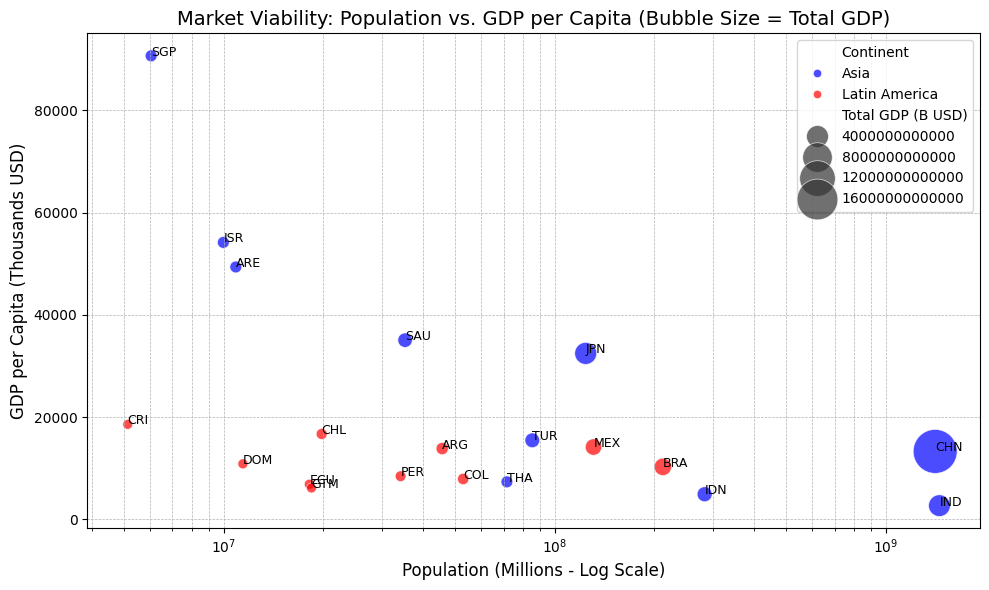

In [ ]:
# Calculate the new variable: Total GDP (in Billions USD)
# (Population in M * GDP per Capita in k USD) -> Billion USD
filtered_df['Total GDP (B USD)'] = filtered_df['Population'] * filtered_df['GDP']
top_df['Total GDP (B USD)'] = top_df['Population'] * top_df['GDP']

# --- VISUALIZATION 1: External Viability (Scatter Plot) ---
plt.figure(figsize=(10, 6))
# Use log scale for Population to handle the wide range of values effectively
scatter = sns.scatterplot(
    data=top_df,
    x='Population',
    y='GDP',
    size='Total GDP (B USD)',
    hue='Continent',
    sizes=(50, 1000), # Define min/max size for markers
    alpha=0.7,
    palette={'Latin America': 'red', 'Asia': 'blue'}
)

# Add annotations (country codes)
for i, row in top_df.iterrows():
    plt.annotate(row['Country Code'], (row['Population'], row['GDP']), fontsize=9)

plt.title('Market Viability: Population vs. GDP per Capita (Bubble Size = Total GDP)', fontsize=14)
plt.xlabel('Population (Millions - Log Scale)', fontsize=12)
plt.ylabel('GDP per Capita (Thousands USD)', fontsize=12)
plt.xscale('log')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

## **The supply distribution plan**

Now that we now which countries are more suitable to establish supply sources or factories and the economic situation of the people living in them (values gotten from the correlations), we have to find which countries are better based on the exportation of supplies considering their goods in the production of raw materials and their political context.

### **Dendogram of geographical distances**

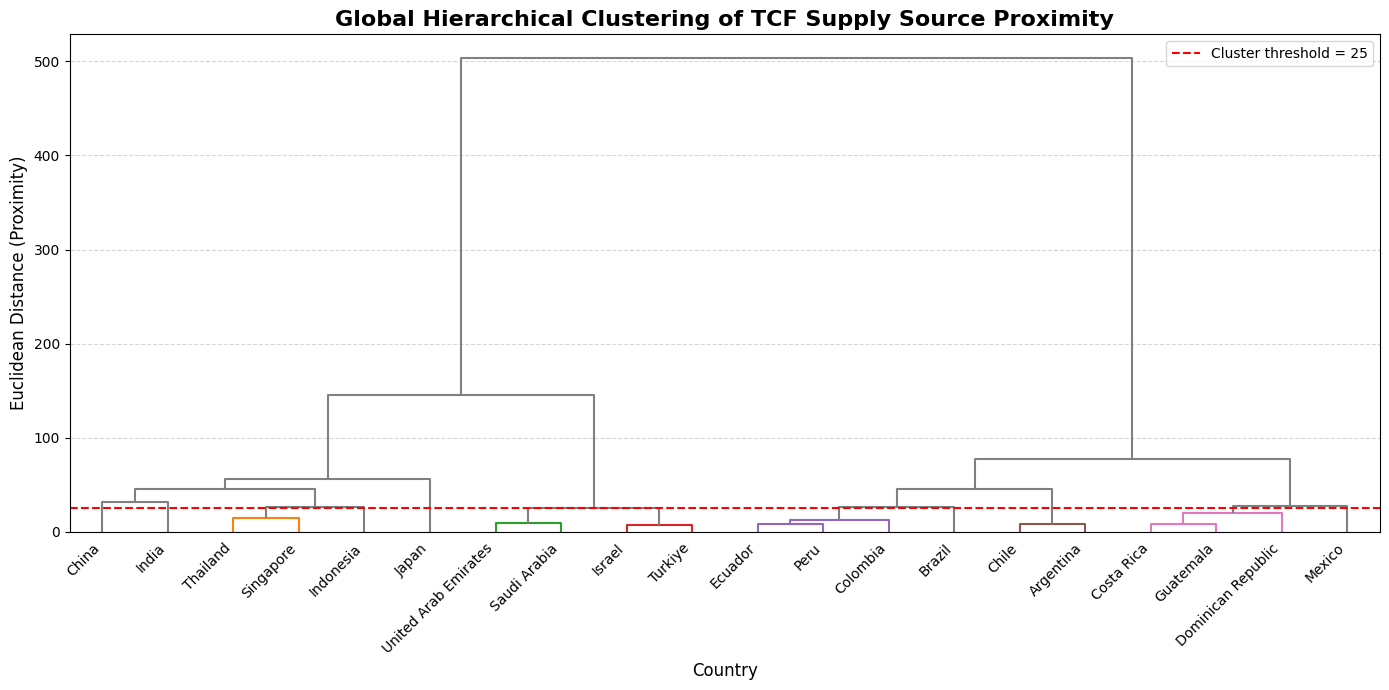

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# --- 1. Geographical Data (Updated) ---
geo_data = {
    'Country Name': [
        'Brazil', 'Mexico', 'Colombia', 'Argentina', 'India', 'China', 'Indonesia', 'Japan',
        'Turkiye', 'Saudi Arabia', 'Singapore', 'Israel', 'United Arab Emirates', 
        'Thailand', 'Chile', 'Peru', 'Ecuador', 'Dominican Republic', 'Guatemala', 'Costa Rica'
    ],
    'Latitude': [
        -10, 23, 4, -34, 20, 35, -5, 36,
        39, 25, 1.3667, 31.5, 24, 15, -30, -10, -2, 19, 15.5, 10
    ],
    'Longitude': [
        -55, -102, -72, -64, 77, 105, 120, 138,
        35, 45, 103.8, 34.75, 54, 100, -71, -76, -77.5, -70.6667, -90.25, -84
    ],
    'Continent': [
        'Latam', 'Latam', 'Latam', 'Latam', 'Asia', 'Asia', 'Asia', 'Asia',
        'Asia', 'Asia', 'Asia', 'Asia', 'Asia', 'Asia', 'Latam', 'Latam', 'Latam', 'Latam', 'Latam', 'Latam'
    ]
}

df_geo = pd.DataFrame(geo_data)

# --- 2. Compute Distance Matrix and Linkage ---
X = df_geo[['Latitude', 'Longitude']].values
country_labels = df_geo['Country Name'].tolist()
distance_matrix = pdist(X, metric='euclidean')
linked = linkage(distance_matrix, method='ward')

# --- 3. Define Color Threshold and Cluster Count ---
# You can tweak `t` to change the number of visible color groups
threshold = 25  # distance threshold
clusters = fcluster(linked, threshold, criterion='distance')

# --- 4. Plot Enhanced Dendrogram ---
plt.figure(figsize=(14, 7))
dendrogram(
    linked,
    orientation='top',
    labels=country_labels,
    distance_sort='descending',
    show_leaf_counts=True,
    color_threshold=threshold,
    above_threshold_color='gray',
)

# --- 5. Enhancing the Plot ---
plt.title('Global Hierarchical Clustering of TCF Supply Source Proximity', fontsize=16, weight='bold')
plt.ylabel('Euclidean Distance (Proximity)', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Cluster threshold = {threshold}')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


### **Organizational structure visualizations**

In [ ]:
# --- 2. Create the Sunburst Chart ---

fig = px.sunburst(
    df_org, 
    names='labels', 
    parents='parents', 
    values='values',
    title='TCF Organizational Structure: Labor Force Distribution',
    height=600,
    color='values',  # Color by employee count
    color_continuous_scale=px.colors.sequential.Viridis # Use a color scale
)

# Customize layout for better display
fig.update_layout(
    font=dict(size=12),
    title_x=0.5, # Center the title
)

# Showing the organizational structure
fig.show()

print("Sunburst chart that represents TCF's departments.")

Sunburst chart that represents TCF's departments.


Looking at the sunburst chart, the organizational structure of Marco's company shows a strong emphasis and in the supply chain and operations departments, which highlights the company's focus on logistics and cost control. This helps to create an expansion strategy based on the employee distribution by departments and subdepartments.

In [ ]:
fig2 = px.treemap(
    df_budget, 
    path=['department', 'project'],  # Defines the hierarchy: Department -> Project
    values='budget',  # Defines the size of each block
    title='TCF Current Strategic Focus: Interactive Project Budget Allocation',
    color='budget',  # Color by budget to show the financing per department
    color_continuous_scale="peach"
)

# Plotting the interactive tree map
fig2.update_traces(textinfo="label+value", textfont_size=11)
fig2.update_layout(height=700, width=1000)
fig2.show()

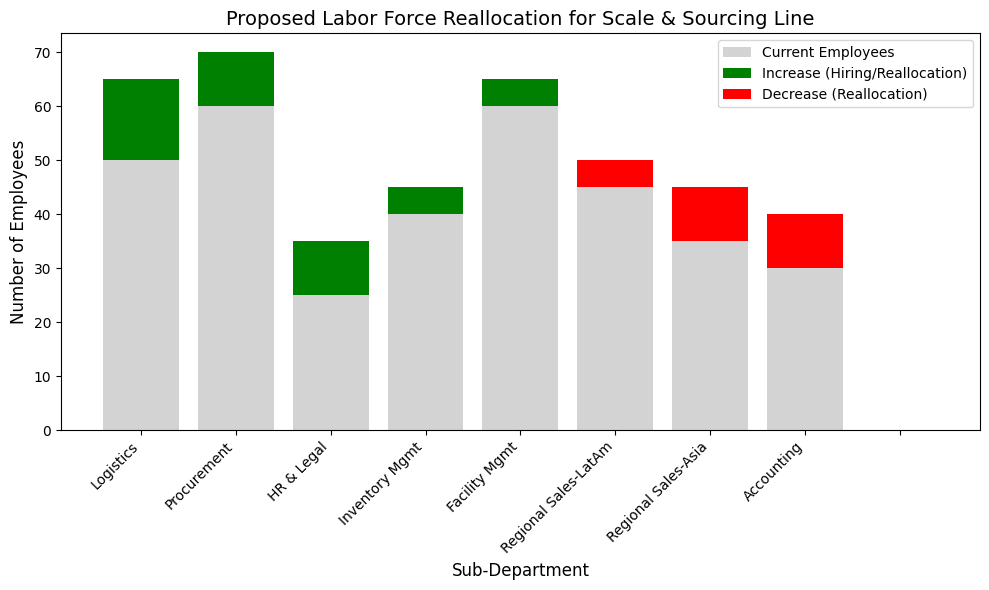

In [ ]:
# Data created: Derived from the current TCF structure and the proposed changes above.
labor_reallocation_data = {
    'Sub-Department': ['Logistics', 'Procurement', 'HR & Legal', 'Inventory Mgmt', 'Facility Mgmt', 'Regional Sales-LatAm', 'Regional Sales-Asia', 'Accounting'],
    'Current Employees': [50, 60, 25, 40, 60, 45, 35, 30],
    'Adjustment': [15, 10, 10, 5, 5, -5, -10, -10] # Net shift is 45 - 25 = +20 (The total workforce increases by 20 with new hires for critical roles)
}
df_labor_change = pd.DataFrame(labor_reallocation_data)

# Create a column for the New Employee Count
df_labor_change['New Employees'] = df_labor_change['Current Employees'] + df_labor_change['Adjustment']

# Determine the change type for coloring
df_labor_change['Change Type'] = df_labor_change['Adjustment'].apply(lambda x: 'Increase' if x > 0 else 'Decrease')

# --- Create the Comparative Bar Chart ---
plt.figure(figsize=(10, 6))

# Use the current workforce as the base bar
plt.bar(df_labor_change['Sub-Department'], df_labor_change['Current Employees'], label='Current Employees', color='lightgrey')

# Use a second bar to show the adjustment (increase/decrease)
# The bottom of the adjustment bar is the current employee count for increases
# The top of the adjustment bar is the new employee count for decreases
for index, row in df_labor_change.iterrows():
    if row['Adjustment'] > 0:
        plt.bar(row['Sub-Department'], row['Adjustment'], bottom=row['Current Employees'], color='green', label='_nolegend_')
    else:
        plt.bar(row['Sub-Department'], row['Adjustment'], bottom=row['Current Employees'] - row['Adjustment'], color='red', label='_nolegend_')

# Re-adding the legend handles (simplifying legend for clarity)
plt.bar([''], [0], color='green', label='Increase (Hiring/Reallocation)')
plt.bar([''], [0], color='red', label='Decrease (Reallocation)')

plt.title('Proposed Labor Force Reallocation for Scale & Sourcing Line', fontsize=14)
plt.xlabel('Sub-Department', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

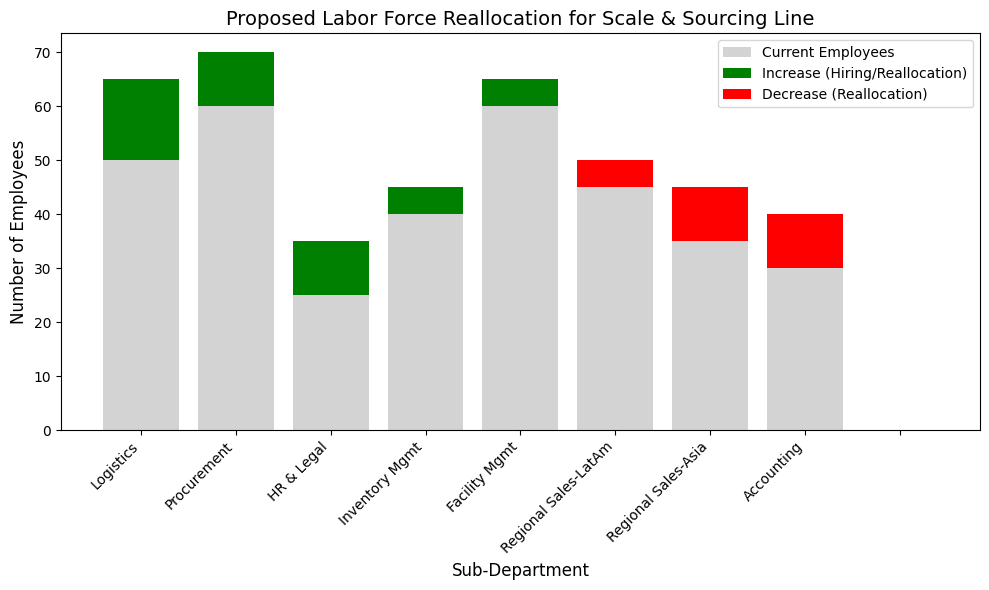

In [ ]:
# Data created: Derived from the current TCF structure and the proposed changes above.
labor_reallocation_data = {
    'Sub-Department': ['Logistics', 'Procurement', 'HR & Legal', 'Inventory Mgmt', 'Facility Mgmt', 'Regional Sales-LatAm', 'Regional Sales-Asia', 'Accounting'],
    'Current Employees': [50, 60, 25, 40, 60, 45, 35, 30],
    'Adjustment': [15, 10, 10, 5, 5, -5, -10, -10] # Net shift is 45 - 25 = +20 (The total workforce increases by 20 with new hires for critical roles)
}
df_labor_change = pd.DataFrame(labor_reallocation_data)

# Create a column for the New Employee Count
df_labor_change['New Employees'] = df_labor_change['Current Employees'] + df_labor_change['Adjustment']

# Determine the change type for coloring
df_labor_change['Change Type'] = df_labor_change['Adjustment'].apply(lambda x: 'Increase' if x > 0 else 'Decrease')

# --- Create the Comparative Bar Chart ---
plt.figure(figsize=(10, 6))

# Use the current workforce as the base bar
plt.bar(df_labor_change['Sub-Department'], df_labor_change['Current Employees'], label='Current Employees', color='lightgrey')

# Use a second bar to show the adjustment (increase/decrease)
# The bottom of the adjustment bar is the current employee count for increases
# The top of the adjustment bar is the new employee count for decreases
for index, row in df_labor_change.iterrows():
    if row['Adjustment'] > 0:
        plt.bar(row['Sub-Department'], row['Adjustment'], bottom=row['Current Employees'], color='green', label='_nolegend_')
    else:
        plt.bar(row['Sub-Department'], row['Adjustment'], bottom=row['Current Employees'] - row['Adjustment'], color='red', label='_nolegend_')

# Re-adding the legend handles (simplifying legend for clarity)
plt.bar([''], [0], color='green', label='Increase (Hiring/Reallocation)')
plt.bar([''], [0], color='red', label='Decrease (Reallocation)')

plt.title('Proposed Labor Force Reallocation for Scale & Sourcing Line', fontsize=14)
plt.xlabel('Sub-Department', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()